<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 172 &middot; Capstone 13 &middot; Kendall's Tau</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Do Two Judges See the Same Thing?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">A blind panel, a dozen products, three judges and a scoring sheet. The question is not who scored highest but whether two experts put the products in the same order, and whether a dozen items is enough to tell.</div>
</div>

In [1]:
import numpy as np, pandas as pd, itertools
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-judges-product-rankings.xlsx"
try:
    raw = pd.read_excel("../../data/" + fn, sheet_name="scores")
except FileNotFoundError:
    raw = pd.read_excel(BASE + fn, sheet_name="scores")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 16 rows


,product,judge_a,judge_b,judge_c
0,Iced Citrus,3,2.0,9.0
1,Fig & Honey,5,4.0,8.0
2,Kiln Toffee,7,7.0,10.0
3,Cedar Smoke,2,1.0,1.0
4,Maple Crisp,3,3.0,NaN


## Step 1 &middot; Goal and hypotheses
A blind tasting panel scored a range of products. Three trained judges worked independently on the same 1-to-10 quality scale. Before the panel's verdict goes anywhere near a product decision, someone should ask whether the judges are actually measuring the same thing.

- **H&#8320; (null):** the two judges' orderings are independent. Knowing where Judge A placed a product tells you nothing about where Judge B placed it.
- **H&#8321; (alternative):** the orderings are associated.
- **&#945; = 0.05.**

The question is about **agreement on order**, not agreement on scores. One judge can be harsher than another across the board and still rank everything identically, and for a product decision that is agreement enough.

## Step 2 &middot; Classify the data
Each judge's score is an **ordinal** variable: 1 to 10, ordered, but with no guarantee that the step from 7 to 8 means the same as the step from 3 to 4. The unit of analysis is the **product**, and there are only a dozen of them, which is what a panel can taste in one sitting before the palate gives out. Small n and ordinal scores together rule out the usual continuous machinery.

## Step 3 &middot; Prepare and clean
Valid scores run 1 to 10. A product only enters the comparison if every judge actually scored it.

In [2]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["judge_a","judge_b","judge_c"]); a_na = len(df)
J = ["judge_a","judge_b","judge_c"]
for j in J: df[j] = df[j].astype(int)
bad = df[~((df[J] >= 1).all(axis=1) & (df[J] <= 10).all(axis=1))]
df = df[(df[J] >= 1).all(axis=1) & (df[J] <= 10).all(axis=1)].sort_values("product").reset_index(drop=True)
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  complete scores {a_na} (-{a_dup-a_na})")
print("out-of-range rows removed:", bad["product"].tolist())
print(f"clean panel: n = {len(df)} products\n")
print(df.to_string(index=False))

start 16  ->  dedup 15 (-1)  ->  complete scores 13 (-2)
out-of-range rows removed: ['Orange Peel']
clean panel: n = 12 products

        product  judge_a  judge_b  judge_c
    Amber Roast        4        5        5
Bourbon Vanilla        5        6        3
    Cedar Smoke        2        1        1
     Dark Cocoa        3        4        6
  Elder Blossom        4        3        2
    Fig & Honey        5        4        8
    Ginger Snap        7        5        5
  Hazel Praline        7        7        7
    Iced Citrus        3        2        9
  Juniper Berry        5        5        4
    Kiln Toffee        7        7       10
 Lavender Cream        4        5        2


**What the cleaning removed.** One duplicate submission, two products a judge never tasted, and one impossible score of 12 on a 10-point sheet. Twelve products survive. That is a small sample, and the rest of the analysis takes that seriously rather than glossing over it.

## Step 4 &middot; Visualize the orderings
Scores are not the interesting object here; **ranks** are. Converting each judge's scores to ranks and joining the same product across judges shows agreement as a set of near-flat lines and disagreement as crossings.

        product  Judge A  Judge B  Judge C
    Amber Roast      8.0      5.5      6.5
Bourbon Vanilla      5.0      3.0      9.0
    Cedar Smoke     12.0     12.0     12.0
     Dark Cocoa     10.5      8.5      5.0
  Elder Blossom      8.0     10.0     10.5
    Fig & Honey      5.0      8.5      3.0
    Ginger Snap      2.0      5.5      6.5
  Hazel Praline      2.0      1.5      4.0
    Iced Citrus     10.5     11.0      2.0
  Juniper Berry      5.0      5.5      8.0
    Kiln Toffee      2.0      1.5      1.0
 Lavender Cream      8.0      5.5     10.5


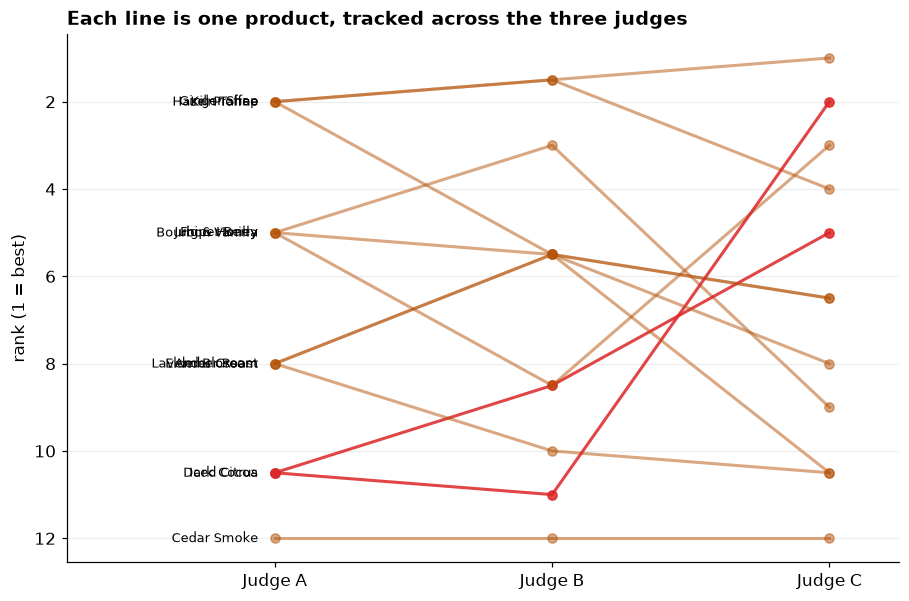

In [3]:
R = df[J].rank(ascending=False, method="average")   # rank 1 = best
R.columns = ["Judge A","Judge B","Judge C"]
R.insert(0, "product", df["product"])
print(R.to_string(index=False))

fig, ax = plt.subplots(figsize=(8.4, 5.6))
xs = [0, 1, 2]
for _, row in R.iterrows():
    ys = [row["Judge A"], row["Judge B"], row["Judge C"]]
    swing = abs(ys[2] - ys[0])
    ax.plot(xs, ys, marker="o", ms=6, lw=2.0,
            color=RD if swing >= 5 else GOLD, alpha=0.85 if swing >= 5 else 0.5)
    ax.text(-0.06, ys[0], row["product"], ha="right", va="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(["Judge A","Judge B","Judge C"])
ax.set_ylabel("rank (1 = best)"); ax.invert_yaxis()
ax.set_xlim(-0.75, 2.25); ax.grid(axis="x", alpha=0)
ax.set_title("Each line is one product, tracked across the three judges")
plt.tight_layout(); plt.show()

**Reading the picture.** Between Judge A and Judge B the lines run mostly flat: the two largely agree about which products are strong and which are weak. Move to Judge C and the picture scrambles, with several lines crossing the whole panel. Iced Citrus in particular sits near the bottom for A and B and near the top for C. That is what disagreement looks like before any coefficient is computed.

## Step 5 &middot; Name the design and choose the measure
Two sets of ordinal ranks over the same twelve items. Two candidates fit: **Spearman's rho** and **Kendall's tau**. We report **tau-b** here for three reasons.

1. **It has a direct meaning.** Tau is built from pairs of products: take any two, and ask whether the judges agree about which is better. Tau is essentially the excess of agreements over disagreements as a proportion of comparable pairs. Rho, by contrast, is a correlation of rank numbers, and its value has no such plain-language reading.
2. **It handles ties explicitly.** With ten score values spread over twelve products, tied scores are certain. The **-b** in tau-b is a correction that accounts for ties in either judge's column.
3. **It behaves better in small samples.** Tau's sampling distribution approaches normality faster than rho's, which matters when n is twelve.

## Step 6 &middot; Count the pairs by hand
Before calling a library, it is worth doing what tau does, once, in the open. Twelve products make 66 pairs.

In [4]:
a = df.judge_a.values; b = df.judge_b.values; n = len(df)
conc = disc = tie_a = tie_b = tie_both = 0
for i, j in itertools.combinations(range(n), 2):
    da, db = np.sign(a[i]-a[j]), np.sign(b[i]-b[j])
    if   da == 0 and db == 0: tie_both += 1
    elif da == 0:             tie_a    += 1
    elif db == 0:             tie_b    += 1
    elif da == db:            conc     += 1
    else:                     disc     += 1
total = n*(n-1)//2
print(f"pairs of products            {total}")
print(f"  concordant (judges agree)  {conc}")
print(f"  discordant (judges differ) {disc}")
print(f"  tied by Judge A only       {tie_a}")
print(f"  tied by Judge B only       {tie_b}")
print(f"  tied by both               {tie_both}")
tau_a_stat = (conc - disc) / total
print(f"\ntau-a (no tie correction) = ({conc} - {disc}) / {total} = {tau_a_stat:.3f}")

pairs of products            66
  concordant (judges agree)  46
  discordant (judges differ) 4
  tied by Judge A only       8
  tied by Judge B only       6
  tied by both               2

tau-a (no tie correction) = (46 - 4) / 66 = 0.636


**The number in plain words.** Of the 66 pairs of products, the judges agreed about which was better in 46 and disagreed in 4. The remaining 16 involve a tie for one judge or both, so they carry no information about agreement and tau-b sets them aside. Uncorrected, that is a tau-a of 0.636; the tie correction raises it, because the pairs being discarded were never disagreements.

## Step 7 &middot; Run the test

In [5]:
tau_ab, p_ab = stats.kendalltau(df.judge_a, df.judge_b)
tau_ac, p_ac = stats.kendalltau(df.judge_a, df.judge_c)
tau_bc, p_bc = stats.kendalltau(df.judge_b, df.judge_c)
rho_ab, p_rho = stats.spearmanr(df.judge_a, df.judge_b)
print(f"n = {n} products\n")
print(f"A vs B   tau-b = {tau_ab:.3f}   p = {p_ab:.5f}   <- the headline")
print(f"A vs C   tau-b = {tau_ac:.3f}   p = {p_ac:.4f}")
print(f"B vs C   tau-b = {tau_bc:.3f}   p = {p_bc:.4f}")
print(f"\nA vs B   Spearman rho = {rho_ab:.3f}   (for comparison)")

n = 12 products

A vs B   tau-b = 0.737   p = 0.00239   <- the headline
A vs C   tau-b = 0.317   p = 0.1780
B vs C   tau-b = 0.181   p = 0.4370

A vs B   Spearman rho = 0.817   (for comparison)


**Reading the results.** Judges A and B agree substantially and the agreement is far too strong to be chance (tau-b = 0.74, p = 0.002). Judge C is a different story: tau-b of 0.32 against A and 0.18 against B, neither significant. Note also that Spearman's rho of 0.82 sits well above tau-b of 0.74 on identical data. That gap is normal. Rho and tau are not two estimates of the same quantity, so they should never be compared as though one were confirming the other, and a report should say which one it is quoting.

## Step 8 &middot; A tau of 0.32 that means nothing
This is the part small samples make vivid. Judge C's 0.32 against Judge A sounds like moderate agreement. Shuffling one judge's scores at random, over and over, shows how large a tau chance alone produces with only twelve products.

null distribution of tau-b with n = 12: sd = 0.244
95% of chance values fall between -0.474 and 0.474
chance alone produces |tau| >= 0.317 in 19.1% of shuffles
chance alone produces |tau| >= 0.737 in 0.1% of shuffles


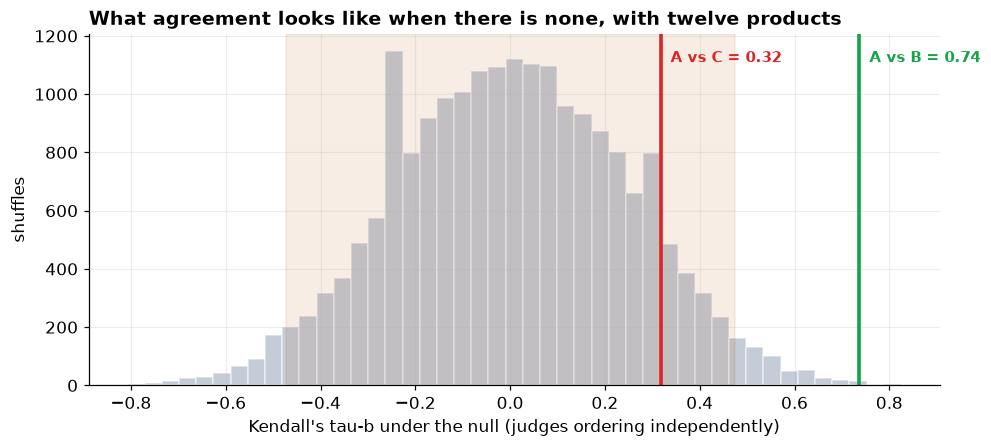

In [6]:
rng = np.random.default_rng(7)
null = np.array([stats.kendalltau(a, rng.permutation(b)).statistic for _ in range(20000)])
print(f"null distribution of tau-b with n = {n}: sd = {null.std():.3f}")
print(f"95% of chance values fall between {np.percentile(null,2.5):.3f} and {np.percentile(null,97.5):.3f}")
print(f"chance alone produces |tau| >= {abs(tau_ac):.3f} in {(np.abs(null) >= abs(tau_ac)).mean()*100:.1f}% of shuffles")
print(f"chance alone produces |tau| >= {abs(tau_ab):.3f} in {(np.abs(null) >= abs(tau_ab)).mean()*100:.1f}% of shuffles")

fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.hist(null, bins=45, color=MUT, alpha=0.55, edgecolor="white")
for v, lab, col in [(tau_ac, f"A vs C = {tau_ac:.2f}", RD), (tau_ab, f"A vs B = {tau_ab:.2f}", GR)]:
    ax.axvline(v, color=col, lw=2.4)
    ax.text(v, ax.get_ylim()[1]*0.92, "  "+lab, color=col, fontweight="bold", fontsize=10)
ax.axvspan(np.percentile(null,2.5), np.percentile(null,97.5), color=GOLD, alpha=0.10)
ax.set_xlabel("Kendall's tau-b under the null (judges ordering independently)")
ax.set_ylabel("shuffles"); ax.set_title("What agreement looks like when there is none, with twelve products")
plt.tight_layout(); plt.show()

**The lesson.** With twelve products, pure chance routinely manufactures a tau of 0.3 or more: the shaded band shows the middle 95 percent of the null distribution reaching to roughly plus or minus 0.47. Judge C's 0.32 sits inside it, so nothing in this panel distinguishes Judge C from someone ordering the products at random. Judge A and B's 0.74 sits far outside. Small samples do not make effects vanish; they make moderate ones unreadable.

## Step 9 &middot; Three judges at once: Kendall's W
Tau compares two rankings. With a whole panel, the natural summary is **Kendall's coefficient of concordance, W**, which runs from 0 (no shared ordering) to 1 (perfect agreement among all judges).

In [7]:
RK = df[J].rank()
m, N = RK.shape[1], RK.shape[0]
Rsum = RK.sum(axis=1)
S = ((Rsum - Rsum.mean())**2).sum()
Tcorr = sum(sum(t**3 - t for t in np.unique(RK[c], return_counts=True)[1]) for c in RK.columns)
W = 12*S / (m**2*(N**3 - N) - m*Tcorr)
chi2_W = m*(N-1)*W
p_W = stats.chi2.sf(chi2_W, N-1)
print(f"Kendall's W = {W:.3f}   chi-square = {chi2_W:.2f}, df = {N-1}, p = {p_W:.4f}")
print("\nagreement between each pair, for context:")
for x, y in [("judge_a","judge_b"), ("judge_a","judge_c"), ("judge_b","judge_c")]:
    print(f"  {x[-1].upper()} vs {y[-1].upper()}: tau-b = {stats.kendalltau(df[x], df[y]).statistic:+.3f}")

Kendall's W = 0.662   chi-square = 21.85, df = 11, p = 0.0255

agreement between each pair, for context:
  A vs B: tau-b = +0.737
  A vs C: tau-b = +0.317
  B vs C: tau-b = +0.181


**What W adds.** The panel as a whole shows moderate concordance (W = 0.66, p = 0.026), enough to reject the idea that all three are ordering independently. But a single panel-level number hides the structure the pairwise taus revealed: two judges who agree closely and a third who does not. Report W and the pairwise coefficients together, or the panel looks more unified than it is.

## Step 10 &middot; Estimate, do not just test
The permutation test settled whether the agreement could be chance. It did not put a range on **how much** the judges agree, and with twelve products that range is the most honest thing this analysis can produce.

In [8]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

tab_lo, tab_hi, reps = boot_ci_pairs(a, b, lambda u, v: stats.kendalltau(u, v).statistic)
cj = df.judge_c.values
tac_lo, tac_hi, _    = boot_ci_pairs(a, cj, lambda u, v: stats.kendalltau(u, v).statistic)
print(f"A vs B   tau-b {tau_ab:+.3f}   95% CI [{tab_lo:+.3f}, {tab_hi:+.3f}]   width {tab_hi-tab_lo:.2f}")
print(f"A vs C   tau-b {tau_ac:+.3f}   95% CI [{tac_lo:+.3f}, {tac_hi:+.3f}]   width {tac_hi-tac_lo:.2f}")

# Kendall's W for the panel, with its own interval.
def W_of(idx):
    R = df.iloc[idx][J].rank()
    m_, N_ = R.shape[1], R.shape[0]
    Rs = R.sum(axis=1)
    S_ = ((Rs - Rs.mean())**2).sum()
    T_ = sum(sum(t**3 - t for t in np.unique(R[col], return_counts=True)[1]) for col in R.columns)
    den = m_**2*(N_**3 - N_) - m_*T_
    return 12*S_/den if den > 0 else np.nan
w_lo, w_hi, _ = boot_ci(np.arange(len(df)), W_of, B=4000, seed=13)
print(f"\nKendall's W    {W:.3f}   95% CI [{w_lo:.3f}, {w_hi:.3f}]")

A vs B   tau-b +0.737   95% CI [+0.427, +0.955]   width 0.53
A vs C   tau-b +0.317   95% CI [-0.280, +0.820]   width 1.10



Kendall's W    0.662   95% CI [0.310, 0.903]


**The intervals are enormous, and that is the finding.** Judge A and B's agreement is somewhere between roughly 0.4 and 0.95. That still rules out "no agreement", which is why the test was significant, but it is a long way from pinning down how closely the two judges track each other. Judge C's interval is wider still and comfortably includes zero.

This is the same lesson the shuffle test taught, stated as estimation rather than as a decision. **Twelve products can establish that two judges agree; they cannot establish by how much.** A panel report quoting "tau = 0.74" without that interval invites a reader to compare it against some other panel's 0.68 and draw a conclusion neither sample could support.

## Step 11 &middot; Interpret in plain language
Judges A and B substantially agree on the order of the twelve products, and the agreement is unlikely to be chance. Judge C does not agree with either at a level this panel can distinguish from random ordering. For the product decision that means the A-and-B consensus is usable, and Judge C's sheet should not simply be averaged in as though it carried the same signal.

The right follow-up is not statistical. Before discarding anyone, find out **why** Judge C differs. A judge trained on a different product category, or one who tasted in a different order, or one reading "quality" as "commercial appeal" rather than craft, will produce exactly this pattern for a reason worth knowing.

## Step 12 &middot; Ethics, bias, and limits
- **A dozen products is a dozen products.** Every estimate here carries wide uncertainty, as the shuffle test showed. Reporting tau-b to three decimals invites more confidence than twelve items can support.
- **Disagreement is not incompetence.** The analysis measures whether two judges ordered the products alike. It cannot say which judge is right. If Judge C is the only one attuned to a quality the others miss, this test would still flag C as the odd one out.
- **Order effects and palate fatigue.** If all judges tasted in the same sequence, agreement is partly agreement about position on the tasting sheet. Randomizing order per judge separates the two; this panel did not record whether that happened, which is a design gap worth closing.
- **Blinding matters.** Judges who can see the brand are scoring the brand. Blind coding is what makes the comparison about the product.
- **Using agreement as a staffing metric is a leap.** A coefficient computed on twelve products should not appear in anyone's performance review. It is a diagnostic for the panel, not a rating of the person.

---
**From analysis to report.** The notebook carries the evidence: the cleaning, the rank picture, the pair counts, tau-b for each pairing, the shuffle test that puts a small sample in its place, and the panel-level W. The written reports turn that into a decision a product lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.